In [20]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import polygamma, loggamma

def p_alpha_j(alpha, j):
    #pmf of sibuya dist.
    return alpha * np.exp(loggamma(j - alpha) - loggamma(j + 1) - loggamma(1 - alpha))

def fisher_info(alpha, j_max=100000):    
    J = np.arange(1, j_max + 1)
    return alpha**(-2) + p_alpha_j(alpha, J)@(1/((J-alpha)*alpha))

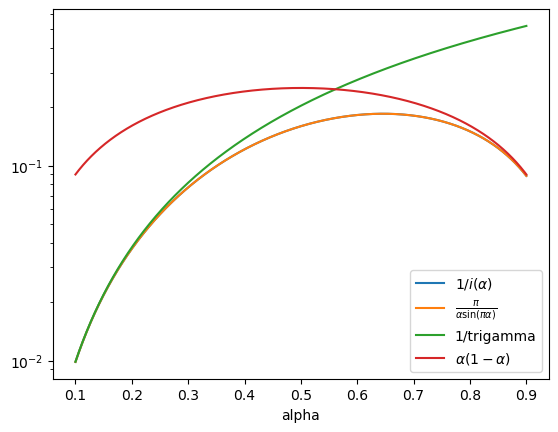

In [35]:
xs = np.linspace(0.1, 0.9, 1000)
ys = np.array([fisher_info(x) for x in xs])
plt.plot(xs, 1/ys, label=r'$1/{i(\alpha)}$')
plt.plot(xs, xs*np.sin(np.pi*xs)/np.pi, label=r'$\frac{\pi}{\alpha\sin(\pi\alpha)}$')
plt.plot(xs, 1/polygamma(1, xs), label='1/trigamma')
plt.plot(xs, xs*(1-xs), label=r'${\alpha(1-\alpha)}$')
plt.yscale('log')
plt.legend()
plt.xlabel('alpha')
plt.savefig('compare', dpi=100)
plt.show()